# Step 1: Installing required library
    - We will need psycopg2-binary for connection with Postgres SQL and running queries 
    - Pandas for dataframe ( stroring data for data manipuitaion, cealning, calcutions etc.)
    - sqlalchemy for creating database connections and interact with databases
    - plotly, seaborn,, matplotlib for visualizations

In [1]:
pip install psycopg2-binary pandas sqlalchemy plotly

Note: you may need to restart the kernel to use updated packages.


# Step 2 - Connecting with DB
 - Connecting with Postgres.

# Note - Please connect with DB for responsive analysis cells.

In [2]:
import os
from pathlib import Path

import pandas as pd
from sqlalchemy import create_engine, text
from dotenv import load_dotenv

# Load .env if present
load_dotenv(".env", override=True)

DATABASE_URL = os.getenv("DB_URL")

try:
    engine = create_engine(DATABASE_URL)
    with engine.connect() as conn:
        result = conn.execute(text("SELECT COUNT(*) FROM candidate_log"))
        print("Connected! Total rows:", result.fetchone()[0])

    df = pd.read_sql("SELECT * FROM candidate_log", engine)
    print("Loaded data from database")

except Exception as e:
    print(f"Database connection failed: {e}")

Connected! Total rows: 8246901
Loaded data from database


# Step 3.A - Knowing our Data
 - We check numbers of columns there data type
 - We check a sample of data for better understanding the data at hand.

In [3]:
df_sample = df.head()
print(df_sample.shape)
print(df_sample.dtypes)
df_sample.head()

(5, 12)
log_id                          int64
candidate_id                   object
logged_at              datetime64[ns]
subject_id                     object
candidate_status               object
question_display_id            object
activity                       object
question_response              object
all_options                    object
question_language              object
question_section               object
question_type                  object
dtype: object


,log_id,candidate_id,logged_at,subject_id,candidate_status,question_display_id,activity,question_response,all_options,question_language,question_section,question_type
0,1068759,MzAxMDA3NzA1Mw==,2025-09-23 13:03:54.166,1,Section 1 Question 23,23,Auto Save,B,"A,B,C,D",HI,1,MCQ
1,1068759,MzAxMzA1NzQxMg==,2025-09-23 16:38:50.732,1,Section 4 Question 13,13,Auto Save,B,"A,B,C,D",EN,4,MCQ
2,1068760,MjIwMTI1MjUxNA==,2025-09-23 09:33:46.192,1,Section 4 Question 5,5,Auto Save,C,"A,B,C,D",EN,4,Comprehension
3,1068760,MjIwMTI1Mzc3MA==,2025-09-23 09:21:12.513,1,Section 2 Question 9,9,Auto Save,B,"A,B,C,D",EN,2,MCQ
4,1068760,MjIwMTI1NTk0Mg==,2025-09-23 09:02:10.543,1,Section 4 Question 9,9,Auto Save,A,"A,B,C,D",EN,4,MCQ


# Step 3.B - Understanding the data.
 -  We already know from the problem statement and above sample data that most of data is system generated data.

In [4]:
query = """
SELECT 
    activity,
    COUNT(*) as count,
    ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 2) AS pct
FROM candidate_log
GROUP BY activity
ORDER BY count DESC
"""
df_activity = pd.read_sql(query, engine)
print(df_activity)

                   activity    count    pct
0                 Auto Save  7482437  90.73
1    Mark for Review & Next   536510   6.51
2  UnMark for Review & Next   227954   2.76


# Step 4 - Data Cleaning & Transformation

### Objective
Prepare raw `candidate_log` data for behavioural analysis by:
- Establishing the correct composite primary key
- Fixing data types for numeric columns
- Standardising missing values in `question_response` and Filtering system-generated Auto Save
- Engineering new features useful for analysis (hour, time slots etc.)

## Step 4.1: Composite Primary Key

The schema explicitly states that `log_id` is unique ONLY when combined 
with `candidate_id`. We create a composite key to correctly identify each row.

In [5]:
df['composite_key'] = df['log_id'].astype(str) + "_" + df['candidate_id'].astype(str)

total_rows = len(df)
unique_keys = df['composite_key'].nunique()

print(f"Total rows       : {total_rows:,}")
print(f"Unique composite keys: {unique_keys:,}")
print(f"Duplicates       : {total_rows - unique_keys:,}")

Total rows       : 8,246,901
Unique composite keys: 8,246,901
Duplicates       : 0


## Step 4.2: Fix Data Types

Several columns were loaded as 'object' (string) but represent numeric values. We cast them to integers for correct aggregation and sorting.

In [6]:
df['question_section'] = pd.to_numeric(df['question_section'], errors='coerce').astype('Int64')
df['question_display_id'] = pd.to_numeric(df['question_display_id'], errors='coerce').astype('Int64')
df['subject_id'] = pd.to_numeric(df['subject_id'], errors='coerce').astype('Int64')
df['logged_at'] = pd.to_datetime(df['logged_at'])

print("Updated dtypes:")
print(df[['question_section','question_display_id','subject_id','logged_at']].dtypes)

Updated dtypes:
question_section                Int64
question_display_id             Int64
subject_id                      Int64
logged_at              datetime64[ns]
dtype: object


## Step 4.3: Standardise Missing Values in `question_response`

Unanswered questions appear as `None` in the database. We replace these with `"No Response"` to make them explicit and easy to filter/group in analysis.

In [7]:
df['question_response'] = df['question_response'].fillna('No Response')

print("Response value counts:")
print(df['question_response'].value_counts())

Response value counts:
question_response
A              2227192
B              1926586
C              1923705
D              1404954
No Response     764464
Name: count, dtype: int64


## Step 4.4: Seperate Out Auto Save Events and feature engeneering

90.73% of rows are system-generated Auto Save pings. These are NOT human interactions and would severely distort any behavioural analysis if retained.

We keep only:
- `Mark for Review & Next` → candidate flagged question and moved on
- `UnMark for Review & Next` → candidate removed the flag

In [8]:
df['hour'] = df['logged_at'].dt.hour
df['minute'] = df['logged_at'].dt.minute
df['time_slot'] = pd.cut(
    df['hour'],
    bins=[8, 10, 12, 14, 16, 18, 20],
    labels=['9-10 AM', '11 AM-12 PM', '1-2 PM', '3-4 PM', '5-6 PM', '7 PM+']
)

df_filtered = df[df['activity'] != 'Auto Save'].copy()
df_raw = df[df['activity'] == 'Auto Save'].copy()

print(f"df_filtered shape: {df_filtered.shape}")
print(f"df_raw shape     : {df_raw.shape}")
print(df_filtered[['logged_at', 'hour', 'time_slot']].head())

df_filtered shape: (764464, 16)
df_raw shape     : (7482437, 16)
                 logged_at  hour    time_slot
19 2025-09-23 12:47:53.047    12  11 AM-12 PM
27 2025-09-23 16:29:18.913    16       3-4 PM
40 2025-09-23 09:02:12.351     9      9-10 AM
43 2025-09-23 09:33:47.735     9      9-10 AM
44 2025-09-23 09:49:24.793     9      9-10 AM


## Step 4.5: Final Cleaned Dataset Summary

In [9]:
print("=" * 45)
print("      CLEANED DATASET SUMMARY")
print("=" * 45)
print(f"Total rows         : {len(df_filtered):,}")
print(f"Unique candidates  : {df_filtered['candidate_id'].nunique():,}")
print(f"Sections covered   : {sorted(df_filtered['question_section'].dropna().unique().tolist())}")
print(f"Activities         : {df_filtered['activity'].unique().tolist()}")
print(f"Date range         : {df_filtered['logged_at'].min()} → {df_filtered['logged_at'].max()}")
print(f"Languages          : {df_filtered['question_language'].unique().tolist()}")
print("=" * 45)

print("=" * 45)
print("      AUTO SAVE EVENT SUMMARY")
print("=" * 45)
print(f"Total rows         : {len(df_raw):,}")
print(f"Unique candidates  : {df_raw['candidate_id'].nunique():,}")
print(f"Sections covered   : {sorted(df_raw['question_section'].dropna().unique().tolist())}")
print(f"Activities         : {df_raw['activity'].unique().tolist()}")
print(f"Date range         : {df_raw['logged_at'].min()} → {df_filtered['logged_at'].max()}")
print(f"Languages          : {df_raw['question_language'].unique().tolist()}")
print("=" * 45)

      CLEANED DATASET SUMMARY
Total rows         : 764,464
Unique candidates  : 79,407
Sections covered   : [1, 2, 3, 4]
Activities         : ['Mark for Review & Next', 'UnMark for Review & Next']
Date range         : 2025-09-23 09:00:13.210000 → 2025-09-23 19:12:32.734000
Languages          : ['HI', 'EN']
      AUTO SAVE EVENT SUMMARY
Total rows         : 7,482,437
Unique candidates  : 87,999
Sections covered   : [1, 2, 3, 4]
Activities         : ['Auto Save']
Date range         : 2025-09-23 09:00:10.056000 → 2025-09-23 19:12:32.734000
Languages          : ['HI', 'EN']


## Analysis 1: Activity Distribution by Section

**Question:** Which sections had the most candidate interactions?

This tells us where candidates spent most of their mental energy — high "Mark for Review" in a section suggests candidates found it difficult and wanted to come back to it.

**Note - Auto save is not a candidate activity hence not included in this particular analysis.**

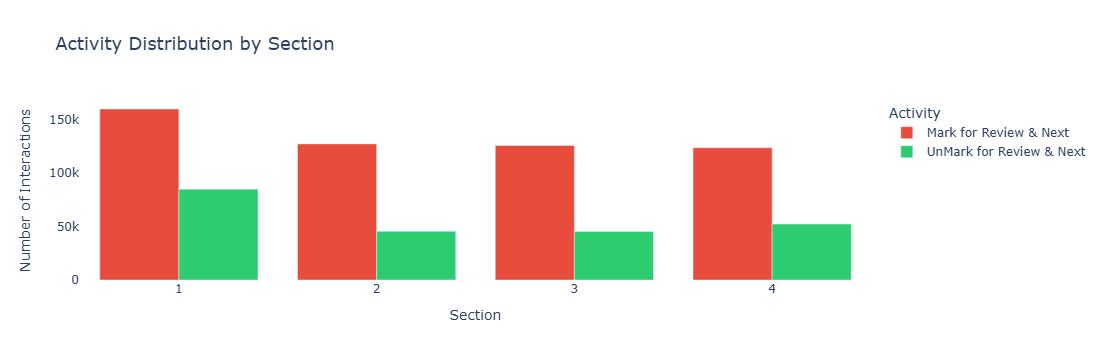

In [10]:
import plotly.express as px

df_section = df_filtered.groupby(['question_section', 'activity']).size().reset_index(name='count')

fig = px.bar(
    df_section,
    x='question_section',
    y='count',
    color='activity',
    barmode='group',
    title='Activity Distribution by Section',
    labels={'question_section': 'Section', 'count': 'Number of Interactions', 'activity': 'Activity'},
    color_discrete_map={
        'Mark for Review & Next': '#E74C3C',
        'UnMark for Review & Next': '#2ECC71'
    }
)

fig.update_layout(
    xaxis=dict(tickmode='linear'),
    plot_bgcolor='white',
    title_font_size=18
)

fig.show()

> **Chart Choice:** Grouped bar chart chosen to compare two activities 
> (Mark vs UnMark) side by side across 4 sections simultaneously. Stacked bar was avoided as it makes individual activity comparison harder.

### Insight: Section 1 had the highest candidate interactions overall
- Section 1 recorded the highest number of both "Mark for Review & Next" (159k) and "UnMark for Review & Next" (84k) interactions.
- The UnMark-to-Mark ratio is also highest in Section 1, indicating that candidates revisited flagged questions more frequently in this section.
- Sections 2, 3, and 4 show very similar interaction volumes, suggesting comparable levels of engagement across these sections.
- Overall, Section 1 stands out as the section where candidates interacted most with the review functionality.

## Analysis 2: Hourly Activity Pattern

**Question:** When were candidates most active during the exam day?

This reveals exam pacing — did candidates rush at the end? Were there peak stress hours?

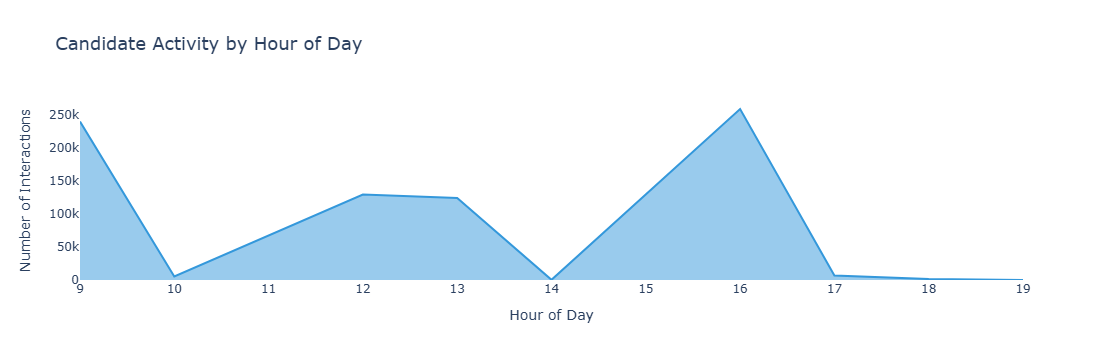

In [11]:
df_hourly = df_filtered.groupby('hour').size().reset_index(name='count')

fig = px.area(
    df_hourly,
    x='hour',
    y='count',
    title='Candidate Activity by Hour of Day',
    labels={'hour': 'Hour of Day', 'count': 'Number of Interactions'},
    color_discrete_sequence=['#3498DB']
)

fig.update_layout(
    plot_bgcolor='white',
    title_font_size=18,
    xaxis=dict(tickmode='linear', dtick=1)
)

fig.show()

> **Chart Choice:** Area chart chosen over line chart to emphasize 
> volume of activity over time. The filled area makes peaks and valleys visually obvious at a glance.

### Insight: Data reveals Multiple Exam Slots
- **Note**: This chart counts behavioural events (Mark/UnMark for Review only). Auto Save events are excluded as they fire automatically and don't  reflect deliberate candidate action.
- The sharp drops at **10:00** and **14:00** are not natural — candidates don't all pause simultaneously
- This pattern strongly suggests **at least 2-3 exam batches** starting at different times (likely 9AM, 11AM, 3PM slots)
- The **peak at 4 PM (258k interactions)** represents the highest simultaneous activity — likely the largest batch mid-exam
- Activity after 17:00 drops sharply as batches conclude
- This is a critical data characteristic that affects any time-based analysis — time should be treated relative to each candidate's start, not absolute clock time

## Analysis 3: Language Preference by Section

**Question:** Do candidates prefer English or Hindi across different sections?

This reveals whether language preference shifts based on subject difficulty — candidates may switch to their native language for harder sections.

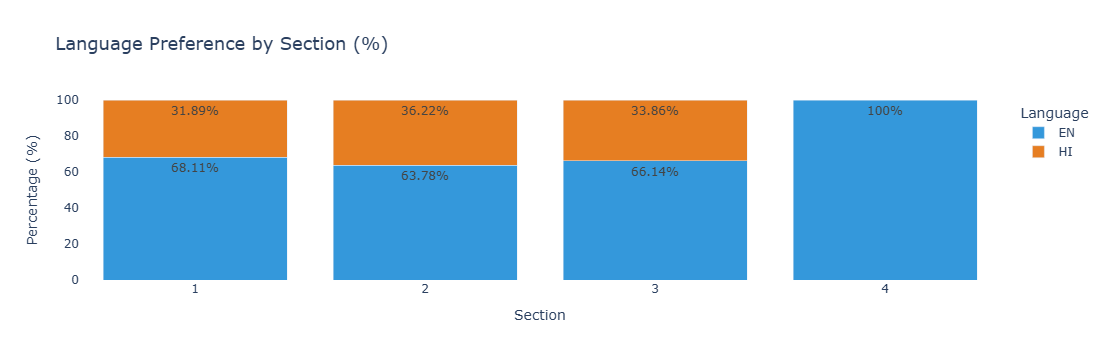

In [12]:
df_lang = df.groupby(['question_section', 'question_language']).size().reset_index(name='count')
df_lang['pct'] = df_lang.groupby('question_section')['count'].transform(lambda x: round(x / x.sum() * 100, 2))

fig = px.bar(
    df_lang,
    x='question_section',
    y='pct',
    color='question_language',
    barmode='stack',
    title='Language Preference by Section (%)',
    labels={
        'question_section': 'Section',
        'pct': 'Percentage (%)',
        'question_language': 'Language'
    },
    color_discrete_map={
        'EN': '#3498DB',
        'HI': '#E67E22'
    },
    text='pct'
)

fig.update_traces(texttemplate='%{text}%', textposition='inside')
fig.update_layout(
    plot_bgcolor='white',
    title_font_size=18,
    xaxis=dict(tickmode='linear'),
    yaxis=dict(range=[0, 100])
)

fig.show()

> **Chart Choice:** Stacked bar chosen specifically to show part-to-whole relationship (EN vs HI as % of 100%) per section. Makes the Section 4 anomaly (100% English) immediately visible.

### Insight: Section 4 was English-Only
- Sections 1, 2, 3 show a **consistent split: ~69% English, ~31% Hindi**
- This consistency suggests language preference is a **candidate-level choice**, not section-dependent
- **Section 4 is 100% English** — this was likely an English-only section with no other option available
- ~31% of candidates attempted in Hindi across sections — a significant minority that the exam platform must support effectively

## Analysis 4: Response Distribution (A/B/C/D)

**Question:** How are candidates distributed across answer choices?

In a fair exam, responses should be roughly equally distributed. Any strong bias toward one option could indicate guessing patterns or question design issues.

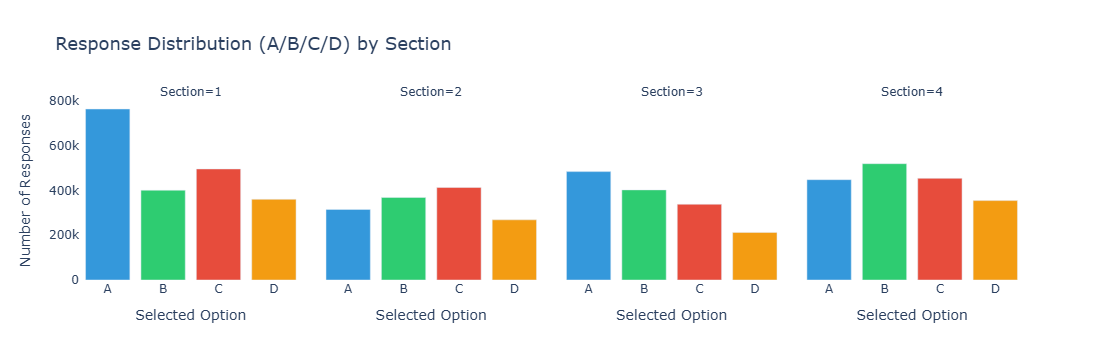

In [13]:
df_resp = df_raw[
    (df_raw['question_response'].notna()) &
    (df_raw['question_response'] != '') &
    (df_raw['question_response'] != 'No Response')
].sort_values('logged_at').drop_duplicates(
    subset=['candidate_id', 'question_section', 'question_display_id'],
    keep='last'
).copy()

df_resp_grouped = df_resp.groupby(['question_section', 'question_response']).size().reset_index(name='count')

fig = px.bar(
    df_resp_grouped,
    x='question_response',
    y='count',
    color='question_response',
    facet_col='question_section',
    title='Response Distribution (A/B/C/D) by Section',
    labels={
        'question_response': 'Selected Option',
        'count': 'Number of Responses',
        'question_section': 'Section'
    },
    color_discrete_map={
        'A': '#3498DB',
        'B': '#2ECC71',
        'C': '#E74C3C',
        'D': '#F39C12'
    }
)

fig.update_layout(
    plot_bgcolor='white',
    title_font_size=18,
    showlegend=False
)

fig.show()

> **Chart Choice:** Faceted bar chart (one panel per section) chosen to compare A/B/C/D distribution within AND across sections simultaneously. A single grouped chart would be too cluttered with 16 bars.

### Insight: Section 1 shows strong Option A bias
- **Section 1** shows a strong skew toward Option A among final submitted answers. Since no answer key is provided, this cannot be interpreted as    correctness or guessing — only as a selection-frequency pattern worth flagging for question design review.
- **Sections 2, 3, 4** are far more evenly distributed — candidates were more deliberate in later sections
- **Option D is consistently the least-selected option** across all sections — worth noting as a pattern, though without an answer key we can't say why
- **Section 3** has the lowest Option D count (~212k) — most skewed away from D of all sections

## Analysis 5: Review Behaviour — Mark vs UnMark Ratio

**Question:** Did candidates who flagged questions actually come back to resolve them?

A high UnMark rate means candidates were engaged and revisiting questions. A low UnMark rate means candidates flagged and abandoned — panic flagging behaviour.

   question_section  Mark for Review & Next  UnMark for Review & Next  \
0                 1                  159844                     84903   
1                 2                  127220                     45492   
2                 3                  125826                     45298   
3                 4                  123620                     52261   

   resolution_rate  
0            53.12  
1            35.76  
2            36.00  
3            42.28  


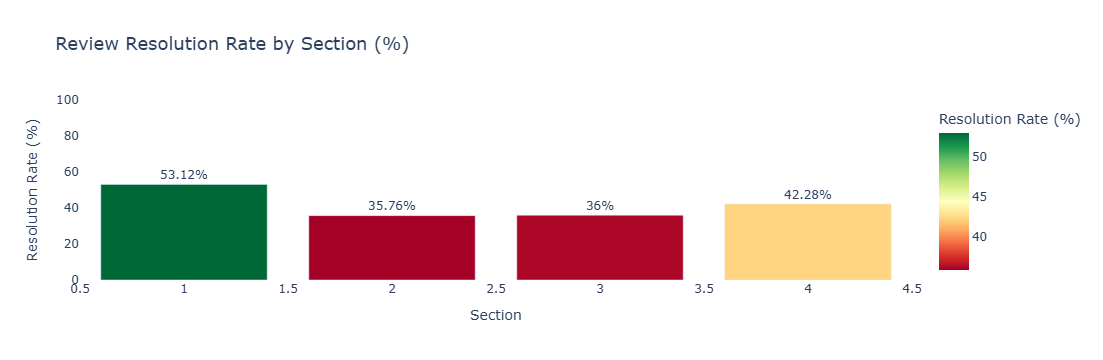

In [14]:
df_review = df_filtered.groupby(['question_section', 'activity']).size().reset_index(name='count')

df_pivot = df_review.pivot(index='question_section', columns='activity', values='count').reset_index()
df_pivot.columns.name = None
df_pivot['resolution_rate'] = round(
    df_pivot['UnMark for Review & Next'] / df_pivot['Mark for Review & Next'] * 100, 2
)

print(df_pivot)

fig = px.bar(
    df_pivot,
    x='question_section',
    y='resolution_rate',
    title='Review Resolution Rate by Section (%)',
    labels={'question_section': 'Section', 'resolution_rate': 'Resolution Rate (%)'},
    color='resolution_rate',
    color_continuous_scale='RdYlGn',
    text='resolution_rate'
)

fig.update_traces(texttemplate='%{text}%', textposition='outside')
fig.update_layout(
    plot_bgcolor='white',
    title_font_size=18,
    yaxis=dict(range=[0, 100])
)

fig.show()

> **Chart Choice:** Single bar chart with color gradient (red→green) chosen to immediately communicate performance — red = low resolution, green = high resolution. Color encodes meaning without needing a legend.

### Insight: Over half of Section 1 reviews were resolved
- **Section 1** had the highest resolution rate at **53.12%** — candidates were most engaged here, actively coming back to reconsider flagged questions
- **Sections 2 & 3** dropped sharply to ~35-36% — candidates flagged but largely abandoned those questions, possibly due to time pressure
- **Section 4** partially recovered at **42.28%** — slight improvement suggesting candidates had more time at the end
- Overall less than half of flagged questions were resolved — indicating widespread time pressure across the exam

## Analysis 6: Candidate Engagement

**Question:** How many candidates interacted with all 4 sections?

This reveals exam completion behaviour — did candidates attempt all sections or drop off midway?

   sections_attempted  candidate_count    pct
0                   4            83899  95.34
1                   3             3743   4.25
2                   2              298   0.34
3                   1               61   0.07


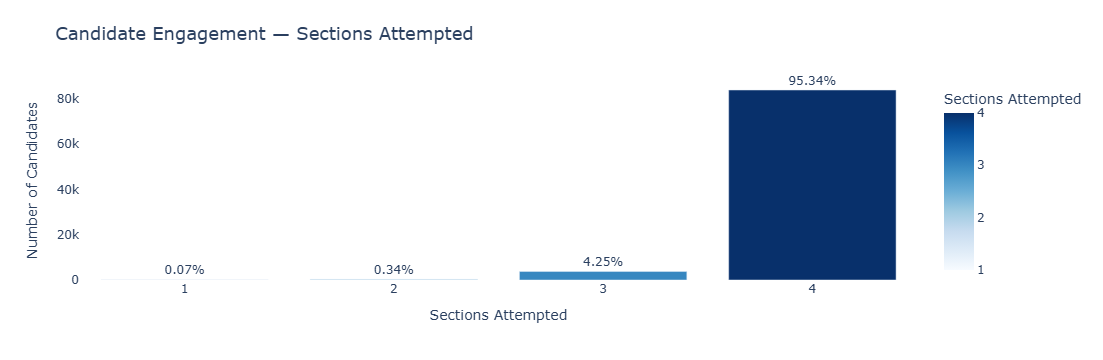

In [15]:
df_engagement = df.groupby('candidate_id')['question_section'].nunique().reset_index()
df_engagement.columns = ['candidate_id', 'sections_attempted']

df_funnel = df_engagement['sections_attempted'].value_counts().sort_index(ascending=False).reset_index()
df_funnel.columns = ['sections_attempted', 'candidate_count']
df_funnel['pct'] = round(df_funnel['candidate_count'] / df_funnel['candidate_count'].sum() * 100, 2)
print(df_funnel)

fig = px.bar(
    df_funnel.sort_values('sections_attempted'),
    x='sections_attempted',
    y='candidate_count',
    title='Candidate Engagement — Sections Attempted',
    labels={
        'sections_attempted': 'Sections Attempted',
        'candidate_count': 'Number of Candidates'
    },
    color='sections_attempted',
    color_continuous_scale='Blues',
    text='pct'
)

fig.update_traces(texttemplate='%{text}%', textposition='outside', cliponaxis=False)
fig.update_layout(
    plot_bgcolor='white',
    title_font_size=18,
    showlegend=False,
    xaxis=dict(tickmode='linear'),
    margin=dict(t=80)
)

fig.show()

> **Chart Choice:** Bar chart chosen over funnel chart after testing — 95.34% of candidates attempted all 4 sections making the funnel visually misleading. Bar chart represents the skewed distribution honestly.

### Insight: 95.34% of candidates attempted all 4 sections
- Overwhelming majority (**83,899 candidates**) engaged with every section
- Only **61 candidates** (0.07%) attempted just 1 section — likely early exits
- This suggests the exam had **strong completion rates** with minimal dropoff
- The small dropoff group (4.66%) likely faced technical issues or time constraints

## Analysis 7: Most Reviewed Questions

**Question:** Which questions were flagged for review the most?

High flag counts on specific questions directly identify the hardest or most confusing questions in the exam.

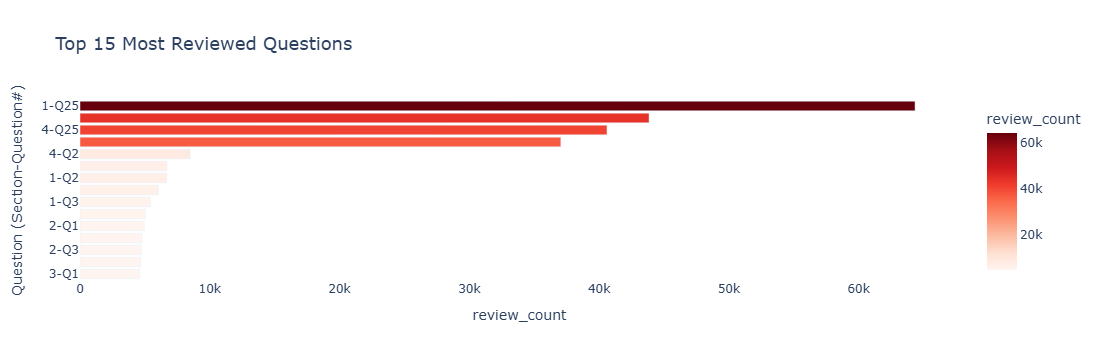

In [16]:
df_most_reviewed = df_filtered[df_filtered['activity'] == 'Mark for Review & Next']\
    .groupby(['question_section', 'question_display_id']).size()\
    .reset_index(name='review_count')\
    .sort_values('review_count', ascending=False)\
    .head(15)

fig = px.bar(
    df_most_reviewed,
    x='review_count',
    y=df_most_reviewed['question_section'].astype(str) + '-Q' + df_most_reviewed['question_display_id'].astype(str),
    orientation='h',
    title='Top 15 Most Reviewed Questions',
    labels={'x': 'Review Count', 'y': 'Question (Section-Question#)'},
    color='review_count',
    color_continuous_scale='Reds'
)

fig.update_layout(
    plot_bgcolor='white',
    title_font_size=18,
    yaxis={'categoryorder': 'total ascending'},
    showlegend=False
)

fig.show()

> **Chart Choice:** Horizontal bar chart chosen because question labels (e.g. "1-Q25") are text and read better on the Y axis. Sorted ascending so highest value is at top — natural reading direction.

### Insight: Question 25 dominates review flags across sections
- **Section 1 - Q25** is the most reviewed question by far (~64k flags) — likely the last question in Section 1, candidates flagged it rushing to move to the next section
- **Section 4 - Q25**, **Section 3 - Q25** and **Section 3 - Q25** also appear in top 3 — Q25 pattern across sections strongly suggests it is the **last question in each section**, flagged as candidates ran out of time
- **Early questions (Q1, Q2, Q3)** also appear — these may have been genuinely confusing, since candidates had plenty of time at the start
- This pattern reveals **two distinct flagging behaviours:**
  1. **Time pressure flagging** — last questions flagged to revisit later
  2. **Difficulty flagging** — early questions flagged due to confusion

## Analysis 8: Average Time Spent per Section

**Question:** How much time did candidates spend on each section on average?

We calculate this using the time difference between first and last event per candidate per section. This reveals which sections demanded the most time and attention.

   question_section  time_spent_mins
0                 1            32.28
1                 2            17.56
2                 3            21.99
3                 4            20.74


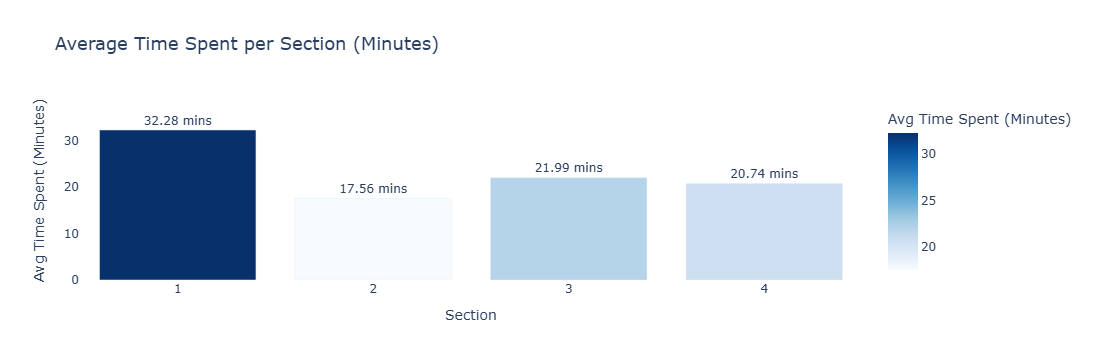

In [17]:
df_time = df.groupby(['candidate_id', 'question_section'])['logged_at'].agg(['min', 'max']).reset_index()
df_time['time_spent_mins'] = (df_time['max'] - df_time['min']).dt.total_seconds() / 60

df_avg_time = df_time.groupby('question_section')['time_spent_mins'].mean().reset_index()
df_avg_time['time_spent_mins'] = round(df_avg_time['time_spent_mins'], 2)
print(df_avg_time)

fig = px.bar(
    df_avg_time,
    x='question_section',
    y='time_spent_mins',
    title='Average Time Spent per Section (Minutes)',
    labels={
        'question_section': 'Section',
        'time_spent_mins': 'Avg Time Spent (Minutes)'
    },
    color='time_spent_mins',
    color_continuous_scale='Blues',
    text='time_spent_mins'
)

fig.update_traces(texttemplate='%{text} mins', textposition='outside')
max_time = df_avg_time['time_spent_mins'].max()

fig.update_layout(
    plot_bgcolor='white',
    title_font_size=18,
    xaxis=dict(tickmode='linear'),
    yaxis=dict(range=[0, max_time * 1.2]),
    showlegend=False
)

fig.show()

> **Chart Choice:** Bar chart with blue gradient chosen to encode time magnitude visually — darker = more time spent. Simple and clean for a straightforward section-by-section comparison.

### Insight: Section 1 demanded the most time of all sections
- **Section 1** had the highest average time at **32.28 mins** — nearly double Section 2, consistent with it having the most review flags and highest interaction count. Candidates were most caution here.
- **Section 2** was the quickest at **17.56 mins** — candidates moved through it fastest, possibly easier content or more confidence
- **Sections 3 & 4** sit in between (~21-22 mins) — moderate, fairly balanced pacing in the latter half of the exam
- This supports Analysis 5 findings — Section 1 had the highest resolution rate AND the most time spent
- **Note** This time-spent metric is now based on the full event timeline (all activity types, not just Mark/UnMark for Review) per candidate per section — capturing actual presence duration rather than just sparse review-flag timestamps